# Buổi 7: Phân tích & dự đoán 

### Phương trình toán học của đường hồi quy: y = ax + b (phương trình đường thẳng)
Advertising Cost: là biến độc lập 
Sales Revenue: là biến phụ thuộc
- Độ dốc là mức độ thay đổi của y nếu x thay đổi 1 đơn vị
- Hệ số chặn là vị trí đường "Best Of Fit" giao với trục y (Điểm ban đầu của dữ liệu)

Chi tiết: 
- x: là biến độc lập
- y: là biến phụ thuộc
- a: là độ dốc (slope)
- b: Hệ số chặn (intercept)

==> Mô hình hồi quy là mối quan hệ giữa các biến. Vì vậy nó có rất nhiều ứng dụng về mặt dự đoán trong các lĩnh vực thực tế.

In [9]:
import pandas as pd

# TẠO DATAFRAME theo cách 1
df_QuangCao = pd.DataFrame( {
    "Advertising Cost": [784, 659, 729, 292],
    "Sales Revenue": [5168, 4736, 4800, 2307]
})



In [10]:
## Tính chỉ số tương quan giữa 2 cột trên
df_QuangCao["Sales Revenue"].corr(df_QuangCao["Advertising Cost"]) # 0.99

np.float64(0.9928277145771283)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
## Lấy dữ liệu X và y từ DF. Lưu ý: phải sử dụng iloc về kết quả trả về phải là một DataFrame
# Cú pháp: df.iloc[hang, cột]
X = df_QuangCao.iloc[:, 0:1]   # Lấy tất cả các hàng, lấy cột 0 => cột độc lập
y = df_QuangCao.iloc[:, 1:2]   # lấy tất cả các hàng, lấy cột 1 => cột phụ thuộc

model.fit(X,y) # Huấn luyện mô hình



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
### Lấy độ dốc  - a
model.coef_

### Lấy hệ số chặn - b
model.intercept_

array([640.5291338])

In [15]:
### Dự đoán doanh thu
model.predict(pd.DataFrame([10000]))

/Users/hieu1966hn/Documents/MindX_Teaching/NPS/NPS-CSA16-HB /.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[59280.47826043]])

### Mini Project 2: Phân tích dự đoán


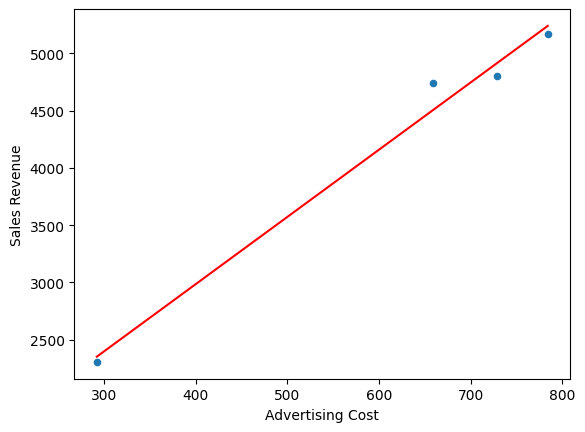

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
## Vẽ biểu đồ phân tán dựa trên dữ liệu df_QuangCao
df_QuangCao.plot.scatter(
    x="Advertising Cost",
    y="Sales Revenue"
)
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) 
# Tạo trục X cho đường thẳng, lấy giá trị nhỏ/ lớn nhất của X => giúp đường thẳng phủ hết vùng dữ liệu
# np.linspace(a, b, 100): Tạo 100 điểm đều nhau từ a -> b
# reshape(-1, 1): Đổi shape thành cột (n,1) => Bắt buộc để phù hợp với model.predict()
y_line = model.coef_[0]*X_line + model.intercept_       # y = ax + b => Là giá trị y trên đường hồi quy
plt.plot(X_line, y_line, color="red", label="Best fit line") # vẽ đường hồi quy
plt.show()
